In [56]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install -U scikit-learn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 119.8 kB/s eta 0:01:04
   -- ------------------------------------- 0.5/8.1 MB 119.8 kB/s eta 0:01:04
   -- ----------

In [14]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import shutil
import random
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import Counter
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Using device: cuda
True
1
NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
#defining paths
data_dir = "./bloodcells_dataset"   
base_dir = "./data_split"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

In [4]:
if os.path.exists(base_dir):
    print("Split already exists. Skipping creation.")
else:
    print("Creating dataset split...")

Split already exists. Skipping creation.


In [5]:
#Create Train/Val/Test directories and split the dataset
if not os.path.exists(base_dir):
    os.makedirs(train_dir)
    os.makedirs(val_dir)
    os.makedirs(test_dir)

    train_ratio = 0.7
    val_ratio = 0.15
    test_ratio = 0.15

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        images = os.listdir(class_path)
        random.shuffle(images)

        total = len(images)
        train_split = int(train_ratio * total)
        val_split = int(val_ratio * total)

        train_images = images[:train_split]
        val_images = images[train_split:train_split + val_split]
        test_images = images[train_split + val_split:]

        for split_name, split_images in zip(
            ["train", "val", "test"],
            [train_images, val_images, test_images]
        ):
            split_class_dir = os.path.join(base_dir, split_name, class_name)
            os.makedirs(split_class_dir, exist_ok=True)

            for img in tqdm(split_images, desc=f"{class_name} → {split_name}"):
                src = os.path.join(class_path, img)
                dst = os.path.join(split_class_dir, img)
                shutil.copyfile(src, dst)

In [6]:
# ImageNet normalization (IMPORTANT for transfer learning later)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [7]:
# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

In [8]:
full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transforms)

In [9]:
# Print dataset info
print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

Classes: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
Total images: 17092


In [10]:
# Split full dataset into train/val/test (if needed for certain models)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

In [11]:
# Override transforms
val_dataset.dataset.transform = val_test_transforms
test_dataset.dataset.transform = val_test_transforms

In [12]:
# Create DataLoaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4,pin_memory=True,persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4,pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4,pin_memory=True)

In [13]:
# Check a batch of data
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [14]:
# Analyze class distribution
from collections import Counter

labels_list = [label for _, label in full_dataset]
class_counts = Counter(labels_list)
print("Class distribution:")
for cls, count in class_counts.items():
    print(f"{full_dataset.classes[cls]}: {count}")

Class distribution:
basophil: 1218
eosinophil: 3117
erythroblast: 1551
ig: 2895
lymphocyte: 1214
monocyte: 1420
neutrophil: 3329
platelet: 2348


In [15]:
# Compute class weights for imbalanced dataset
import numpy as np
counts = np.array(list(class_counts.values()))
weights = 1. / counts
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class weights: tensor([0.0008, 0.0003, 0.0006, 0.0003, 0.0008, 0.0007, 0.0003, 0.0004],
       device='cuda:0')


In [ ]:
#STEP-4 TRANSFER LEARNING (ResNet50 — PyTorch)

In [70]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [71]:
# Load pre-trained ResNet50 model
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

In [72]:
# Freeze Base layer
for param in model.parameters():
    param.requires_grad = False

In [73]:
num_classes = 8

model.fc = nn.Linear(model.fc.in_features, num_classes)

In [74]:
# Move model to device RTX 4050 for faster training
model = model.to(device)

In [75]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [76]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss() 

In [77]:
# Only parameters of the final layer are being optimized
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [78]:
# Define learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.3)

In [ ]:
# # Training Function
# def train_model(model, train_loader, val_loader, epochs=10):
#     for epoch in range(epochs):
#         model.train()
#         running_loss = 0.0
#         for images, labels in train_loader:
#             images, labels = images.to(device), labels.to(device)
#             optimizer.zero_grad()
#             outputs = model(images)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()
#             running_loss += loss.item()
#         # Validation
#         model.eval()
#         val_loss = 0.0
#         correct = 0
#         total = 0
#         with torch.no_grad():
#             for images, labels in val_loader:
#                 images, labels = images.to(device), labels.to(device)
#                 outputs = model(images)
#                 loss = criterion(outputs, labels)
#                 val_loss += loss.item()
#                 _, preds = torch.max(outputs, 1)
#                 correct += (preds == labels).sum().item()
#                 total += labels.size(0)
#         val_accuracy = correct / total
#         scheduler.step(val_loss)
#         print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {running_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

In [79]:
def train_model(model, train_loader, val_loader, optimizer, epochs=5):
    
    for epoch in range(epochs):
        # TRAINING
        model.train()
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_acc = train_correct / train_total

        # VALIDATION
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

In [81]:
#Training the model
train_model(model, train_loader, val_loader,optimizer,epochs=10)

Epoch 1: Train Acc = 0.7589, Val Acc = 0.8541
Epoch 2: Train Acc = 0.8753, Val Acc = 0.8787
Epoch 3: Train Acc = 0.8998, Val Acc = 0.8997
Epoch 4: Train Acc = 0.9145, Val Acc = 0.9048
Epoch 5: Train Acc = 0.9208, Val Acc = 0.9083
Epoch 6: Train Acc = 0.9316, Val Acc = 0.9153
Epoch 7: Train Acc = 0.9376, Val Acc = 0.9185
Epoch 8: Train Acc = 0.9430, Val Acc = 0.9220
Epoch 9: Train Acc = 0.9469, Val Acc = 0.9196
Epoch 10: Train Acc = 0.9485, Val Acc = 0.9227


In [82]:
# Unfreeze all layers for fine-tuning 
for param in model.parameters():
    param.requires_grad = True

In [83]:
# Define a smaller learning rate for fine-tuning
optimizer = optim.Adam(model.parameters(), lr=1e-5)

In [84]:
# Save the fine-tuned model
torch.save(model.state_dict(), "resnet50_model.pth")

In [ ]:
#STEP-5 TRAIN MULTIPLE MODELS (EfficientNet + MobileNet)

In [93]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

In [94]:
# Load pre-trained EfficientNet-B0 model
eff_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

In [95]:
eff_model.classifier[1] = nn.Linear(eff_model.classifier[1].in_features, num_classes)

In [96]:
# Move model to device
eff_model = eff_model.to(device)

In [97]:
# Freeze Base layer
for param in eff_model.parameters():
    param.requires_grad = False
for param in eff_model.classifier.parameters():
    param.requires_grad = True

In [98]:
# Define loss function and optimizer for EfficientNet
eff_optimizer = optim.Adam(eff_model.classifier.parameters(), lr=0.001)

In [99]:
# Fine-tune the EfficientNet model
train_model(eff_model, train_loader, val_loader, eff_optimizer, epochs=10)

Epoch 1: Train Acc = 0.6842, Val Acc = 0.8151
Epoch 2: Train Acc = 0.7897, Val Acc = 0.8432
Epoch 3: Train Acc = 0.8154, Val Acc = 0.8517
Epoch 4: Train Acc = 0.8195, Val Acc = 0.8568
Epoch 5: Train Acc = 0.8310, Val Acc = 0.8611
Epoch 6: Train Acc = 0.8347, Val Acc = 0.8603
Epoch 7: Train Acc = 0.8350, Val Acc = 0.8568
Epoch 8: Train Acc = 0.8394, Val Acc = 0.8689
Epoch 9: Train Acc = 0.8366, Val Acc = 0.8701
Epoch 10: Train Acc = 0.8426, Val Acc = 0.8681


In [35]:
# # Unfreeze all layers for fine-tuning
# for param in eff_model.parameters():
#     param.requires_grad = True

# eff_optimizer = optim.Adam(eff_model.parameters(), lr=1e-5)
# train_model(eff_model, train_loader, val_loader, epochs=5)

Epoch [1/5]:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch [1/5]: 100%|██████████| 374/374 [00:55<00:00,  6.72it/s, loss=2.08]


Train Loss: 781.1005 | Val Loss: 169.0972 | Val Acc: 0.1241


Epoch [2/5]: 100%|██████████| 374/374 [00:56<00:00,  6.61it/s, loss=2.13]


Train Loss: 781.9235 | Val Loss: 169.0464 | Val Acc: 0.1260


Epoch [3/5]: 100%|██████████| 374/374 [00:54<00:00,  6.85it/s, loss=2.14]


Train Loss: 781.5161 | Val Loss: 169.1195 | Val Acc: 0.1260


Epoch [4/5]: 100%|██████████| 374/374 [00:54<00:00,  6.83it/s, loss=2.1] 


Train Loss: 781.2805 | Val Loss: 169.1221 | Val Acc: 0.1260


Epoch [5/5]: 100%|██████████| 374/374 [00:54<00:00,  6.84it/s, loss=2.1] 


Train Loss: 782.3649 | Val Loss: 169.0170 | Val Acc: 0.1245


In [100]:
# Save the fine-tuned EfficientNet model
torch.save(eff_model.state_dict(), "efficientnet_model.pth")

In [101]:
# Load pre-trained MobileNetV2 model
mob_model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

In [102]:
mob_model.classifier[1] = nn.Linear(mob_model.last_channel, num_classes)

In [103]:
mob_model = mob_model.to(device)

In [104]:
# Freeze Base layer
for param in mob_model.parameters():
    param.requires_grad = False
for param in mob_model.classifier.parameters():
    param.requires_grad = True

In [105]:
# Define loss function and optimizer for MobileNetV2
mob_optimizer = optim.Adam(mob_model.classifier.parameters(), lr=0.001)

In [106]:
# Fine-tune the MobileNetV2 model
train_model(mob_model, train_loader, val_loader, mob_optimizer, epochs=10)

Epoch 1: Train Acc = 0.7242, Val Acc = 0.8478
Epoch 2: Train Acc = 0.8433, Val Acc = 0.8646
Epoch 3: Train Acc = 0.8639, Val Acc = 0.8685
Epoch 4: Train Acc = 0.8784, Val Acc = 0.8779
Epoch 5: Train Acc = 0.8815, Val Acc = 0.8861
Epoch 6: Train Acc = 0.8884, Val Acc = 0.8904
Epoch 7: Train Acc = 0.8903, Val Acc = 0.8904
Epoch 8: Train Acc = 0.8953, Val Acc = 0.8872
Epoch 9: Train Acc = 0.8946, Val Acc = 0.8904
Epoch 10: Train Acc = 0.8918, Val Acc = 0.8943


In [43]:
# # Unfreeze all layers for fine-tuning
# for param in mob_model.parameters():
#     param.requires_grad = True

# mob_optimizer = optim.Adam(mob_model.parameters(), lr=1e-5)
# train_model(mob_model, train_loader, val_loader, epochs=5)

Epoch [1/5]: 100%|██████████| 374/374 [00:41<00:00,  9.00it/s, loss=2.06]


Train Loss: 779.2469 | Val Loss: 168.4866 | Val Acc: 0.1654


Epoch [2/5]: 100%|██████████| 374/374 [00:41<00:00,  9.09it/s, loss=2.09]


Train Loss: 778.8404 | Val Loss: 168.4696 | Val Acc: 0.1670


Epoch [3/5]: 100%|██████████| 374/374 [00:41<00:00,  9.10it/s, loss=2.1] 


Train Loss: 778.9735 | Val Loss: 168.5263 | Val Acc: 0.1650


Epoch [4/5]: 100%|██████████| 374/374 [00:41<00:00,  9.11it/s, loss=2.06]


Train Loss: 778.7109 | Val Loss: 168.4951 | Val Acc: 0.1643


Epoch [5/5]: 100%|██████████| 374/374 [00:41<00:00,  9.10it/s, loss=2.11]


Train Loss: 778.8275 | Val Loss: 168.5046 | Val Acc: 0.1631


In [107]:
# Save the fine-tuned MobileNetV2 model
torch.save(mob_model.state_dict(), "mobilenet_model.pth")

In [ ]:
#STEP-6 STACKING ENSEMBLE

In [110]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [111]:
resnet_model.eval()
eff_model.eval()
mob_model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [112]:
def get_preds_and_labels(model, loader):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.vstack(all_preds), np.hstack(all_labels)

In [114]:
# Get predictions from each model on the validation set
resnet_preds, meta_y = get_preds_and_labels(model, val_loader)
eff_preds, _ = get_preds_and_labels(eff_model, val_loader)
mob_preds, _ = get_preds_and_labels(mob_model, val_loader)

In [115]:
print(resnet_preds.shape)  # (N, 8)
print(eff_preds.shape)
print(mob_preds.shape)
print(meta_y.shape)        # (N,)

(2563, 8)
(2563, 8)
(2563, 8)
(2563,)


In [116]:
# Combine predictions for meta-model training
meta_X = np.hstack((resnet_preds, eff_preds, mob_preds))

In [117]:
from sklearn.ensemble import RandomForestClassifier

meta_model = RandomForestClassifier(n_estimators=200)
meta_model.fit(meta_X, meta_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# Use the ResNet instance named `model` (ensures model on device)
resnet_test, test_y = get_preds_and_labels(model, test_loader)

eff_test, _ = get_preds_and_labels(eff_model, test_loader)
mob_test, _ = get_preds_and_labels(mob_model, test_loader)

meta_test_X = np.hstack((resnet_test, eff_test, mob_test))


In [120]:
from sklearn.metrics import accuracy_score

final_preds = meta_model.predict(meta_test_X)
print("Stacking Accuracy:", accuracy_score(test_y, final_preds))

Stacking Accuracy: 0.9481481481481482


In [121]:
print("ResNet:", accuracy_score(test_y, np.argmax(resnet_test, axis=1)))
print("EfficientNet:", accuracy_score(test_y, np.argmax(eff_test, axis=1)))
print("MobileNet:", accuracy_score(test_y, np.argmax(mob_test, axis=1)))
print("Stacking:", accuracy_score(test_y, final_preds))

ResNet: 0.9220272904483431
EfficientNet: 0.8705653021442495
MobileNet: 0.8955165692007797
Stacking: 0.9481481481481482


In [122]:
# Calculate accuracy
accuracy = accuracy_score(test_y, final_preds)
print("Stacked Model Accuracy:", accuracy)

Stacked Model Accuracy: 0.9481481481481482


In [ ]:
#STEP-7 EVALUATION AND VISUALIZATION

In [123]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [124]:
# Confusion Matrix
# Use the underlying dataset to get class names
print(classification_report(test_y, final_preds, target_names=train_dataset.dataset.classes))

              precision    recall  f1-score   support

    basophil       0.93      0.97      0.95       193
  eosinophil       0.99      0.99      0.99       499
erythroblast       0.94      0.94      0.94       210
          ig       0.89      0.90      0.89       417
  lymphocyte       0.95      0.94      0.94       171
    monocyte       0.92      0.84      0.88       219
  neutrophil       0.94      0.96      0.95       478
    platelet       0.99      0.99      0.99       378

    accuracy                           0.95      2565
   macro avg       0.94      0.94      0.94      2565
weighted avg       0.95      0.95      0.95      2565



In [125]:
# Plot confusion matrix
cm = confusion_matrix(test_y, final_preds)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002615BBCA340>
Traceback (most recent call last):
  File "c:\Users\Harsh\anaconda3\envs\minor_project_env\Lib\site-packages\torch\utils\data\dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "c:\Users\Harsh\anaconda3\envs\minor_project_env\Lib\site-packages\torch\utils\data\dataloader.py", line 1621, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


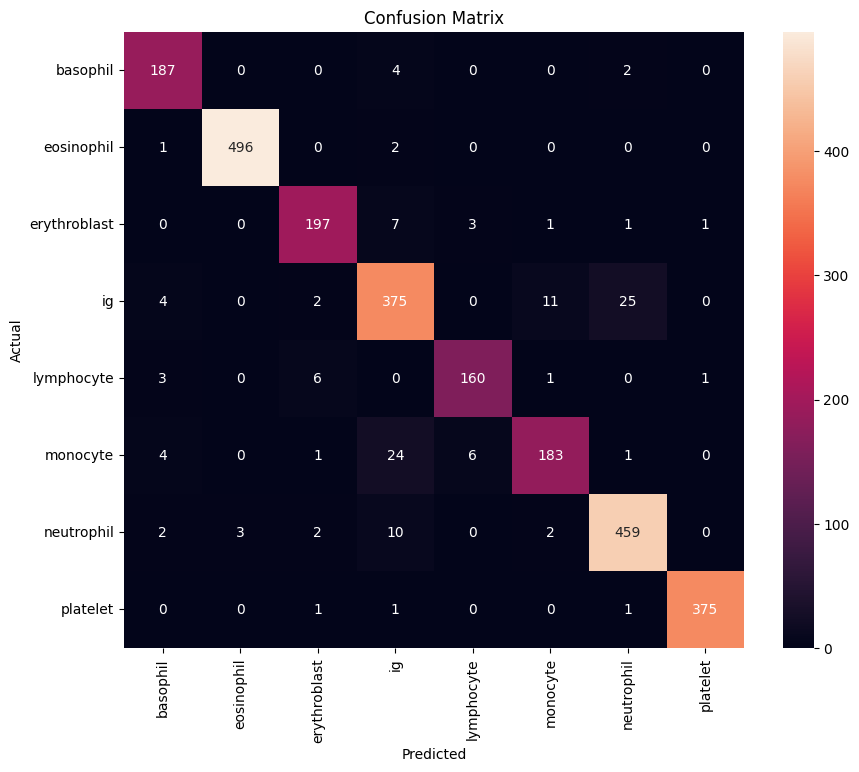

In [126]:
# Visualize confusion matrix with seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=train_dataset.dataset.classes,
            yticklabels=train_dataset.dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [127]:
# Calculate per-class accuracy
import numpy as np

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(per_class_accuracy):
    print(f"{train_dataset.dataset.classes[i]}: {acc:.2f}")

basophil: 0.97
eosinophil: 0.99
erythroblast: 0.94
ig: 0.90
lymphocyte: 0.94
monocyte: 0.84
neutrophil: 0.96
platelet: 0.99


In [128]:
# Visualize per-class accuracy
transforms.RandomRotation(30)
transforms.RandomResizedCrop(224)

RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)

In [129]:
from sklearn.ensemble import RandomForestClassifier
# Train a more complex meta-model (Random Forest)
meta_model = RandomForestClassifier(n_estimators=100)
meta_model.fit(meta_X, meta_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [130]:
from sklearn.metrics import accuracy_score
# Calculate accuracy for each individual model
print("ResNet:", accuracy_score(test_y, np.argmax(resnet_test, axis=1)))
print("EfficientNet:", accuracy_score(test_y, np.argmax(eff_test, axis=1)))
print("MobileNet:", accuracy_score(test_y, np.argmax(mob_test, axis=1)))
print("Stacking:", accuracy_score(test_y, final_preds))

ResNet: 0.9220272904483431
EfficientNet: 0.8705653021442495
MobileNet: 0.8955165692007797
Stacking: 0.9481481481481482


In [131]:
import joblib

joblib.dump(meta_model, "meta_model.pkl")
torch.save(resnet_model.state_dict(), "resnet.pth")
torch.save(eff_model.state_dict(), "eff.pth")
torch.save(mob_model.state_dict(), "mob.pth")

In [132]:
def predict_image(image):
    image = val_test_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():
        r = torch.softmax(resnet_model(image), dim=1)
        e = torch.softmax(eff_model(image), dim=1)
        m = torch.softmax(mob_model(image), dim=1)

    features = torch.cat((r, e, m), dim=1).cpu().numpy()
    pred = meta_model.predict(features)

    return train_dataset.classes[pred[0]]

In [133]:
def predict_image(image):
    image = val_test_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():
        r = torch.softmax(resnet_model(image), dim=1)
        e = torch.softmax(eff_model(image), dim=1)
        m = torch.softmax(mob_model(image), dim=1)

    features = torch.cat((r, e, m), dim=1).cpu().numpy()
    pred = meta_model.predict(features)

    return train_dataset.classes[pred[0]]

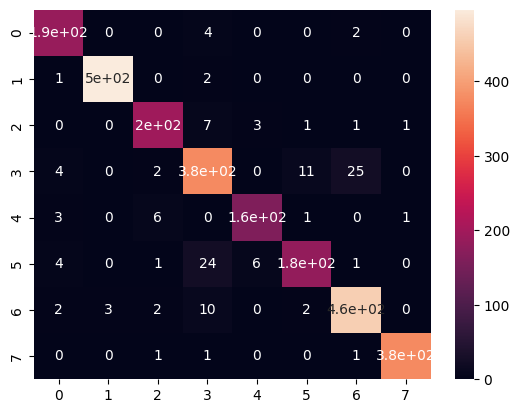

In [134]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_y, final_preds)

sns.heatmap(cm, annot=True)
plt.show()

In [135]:
import torch
import joblib

# Save deep learning models
torch.save(resnet_model.state_dict(), "resnet_model.pth")
torch.save(eff_model.state_dict(), "efficientnet_model.pth")
torch.save(mob_model.state_dict(), "mobilenet_model.pth")

# Save meta model
joblib.dump(meta_model, "meta_model.pkl")

['meta_model.pkl']

In [137]:
joblib.dump(train_dataset.dataset.classes, "class_names.pkl")

['class_names.pkl']

In [138]:
joblib.dump(final_preds, "final_predictions.pkl")
joblib.dump(test_y, "true_labels.pkl")

['true_labels.pkl']

In [139]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_y, final_preds)
joblib.dump(cm, "confusion_matrix.pkl")

['confusion_matrix.pkl']

In [ ]:
# Load models
resnet_model.load_state_dict(torch.load("resnet_model.pth"))
eff_model.load_state_dict(torch.load("efficientnet_model.pth"))
mob_model.load_state_dict(torch.load("mobilenet_model.pth"))

resnet_model.eval()
eff_model.eval()
mob_model.eval()

# Load meta model
meta_model = joblib.load("meta_model.pkl")

# Load classes
class_names = joblib.load("class_names.pkl")

# PREDICTIVE SYSTEM

In [1]:
import torch
import joblib
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load class names
class_names = joblib.load("class_names.pkl")
num_classes = len(class_names)

In [11]:
resnet_model = models.resnet50(weights=None)

resnet_model.fc = nn.Sequential(
    nn.Linear(resnet_model.fc.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, num_classes)
)

resnet_model.load_state_dict(torch.load("resnet_model.pth"))
resnet_model = resnet_model.to(device)
resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [6]:
from torchvision.models import efficientnet_b0

eff_model = efficientnet_b0(weights=None)
eff_model.classifier[1] = nn.Linear(eff_model.classifier[1].in_features, num_classes)
eff_model.load_state_dict(torch.load("efficientnet_model.pth"))
eff_model = eff_model.to(device)
eff_model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [7]:
from torchvision.models import mobilenet_v2

mob_model = mobilenet_v2(weights=None)
mob_model.classifier[1] = nn.Linear(mob_model.last_channel, num_classes)
mob_model.load_state_dict(torch.load("mobilenet_model.pth"))
mob_model = mob_model.to(device)
mob_model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [8]:
meta_model = joblib.load("meta_model.pkl")

In [9]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [10]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        r = torch.softmax(resnet_model(image), dim=1)
        e = torch.softmax(eff_model(image), dim=1)
        m = torch.softmax(mob_model(image), dim=1)

    # Combine features
    features = torch.cat((r, e, m), dim=1).cpu().numpy()

    # Final prediction
    pred = meta_model.predict(features)[0]

    return class_names[pred]

In [27]:
image_path = "bloodcells_dataset\\monocyte\\MO_3281.jpg"   # replace with your image
result = predict_image(image_path)

print("Predicted Cell Type:", result)

Predicted Cell Type: monocyte
